In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [4]:
# LOAD DATASETS

client_df = pd.read_csv("client_data.csv")
price_df = pd.read_csv("price_data.csv")

In [5]:
# VIEW DATA

client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [6]:
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [7]:
# CHECK SHAPE

print(client_df.shape)
print(price_df.shape)

(14606, 26)
(193002, 8)


In [8]:
# CHECK DATA TYPES

client_df.info()
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [9]:
# CONVERT DATE COLUMNS

date_columns = [
    'date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal'
]

for col in date_columns:
    client_df[col] = pd.to_datetime(client_df[col])

price_df['price_date'] = pd.to_datetime(
    price_df['price_date']
)

In [10]:
# DESCRIPTIVE STATISTICS

client_df.describe()
price_df.describe()

,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,2015-06-16 12:50:49.933161216,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
min,2015-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015-04-01 00:00:00,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,2015-07-01 00:00:00,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,2015-10-01 00:00:00,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,2015-12-01 00:00:00,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221
std,NaN,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592


In [11]:
# MISSING VALUES

client_df.isnull().sum()
price_df.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

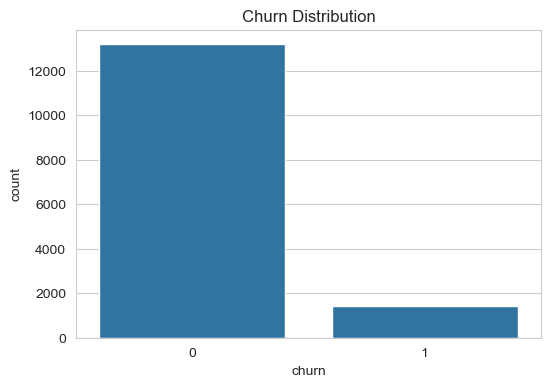

In [12]:
# CHURN DISTRIBUTION

plt.figure(figsize=(6,4))

sns.countplot(
    x='churn',
    data=client_df
)

plt.title("Churn Distribution")

plt.show()

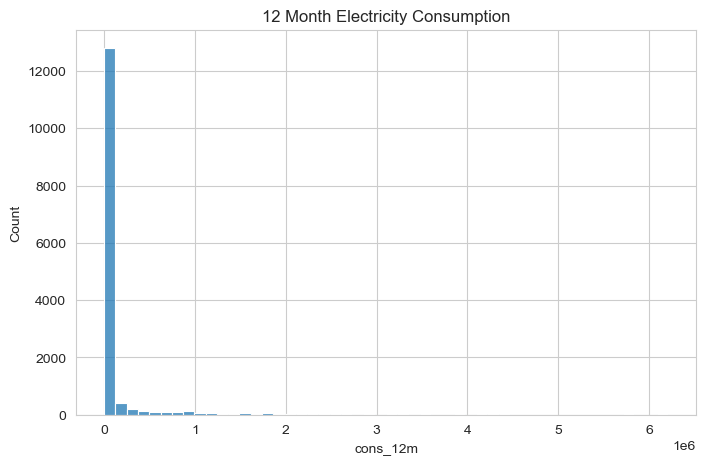

In [13]:
# ELECTRICITY CONSUMPTION DISTRIBUTION

plt.figure(figsize=(8,5))

sns.histplot(
    client_df['cons_12m'],
    bins=50
)

plt.title("12 Month Electricity Consumption")

plt.show()

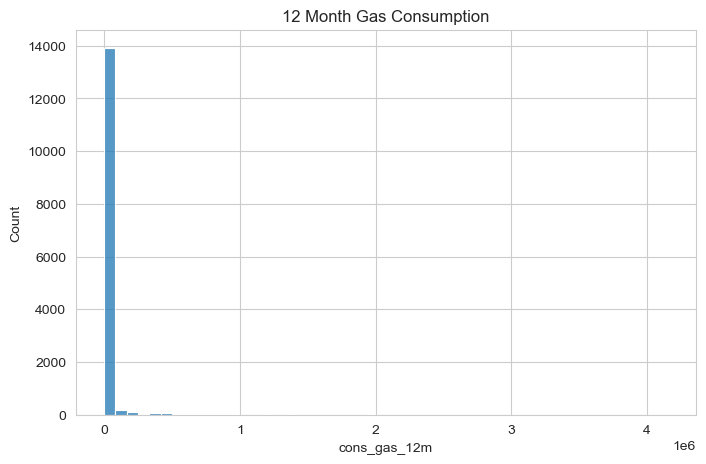

In [14]:
# GAS CONSUMPTION DISTRIBUTION

plt.figure(figsize=(8,5))

sns.histplot(
    client_df['cons_gas_12m'],
    bins=50
)

plt.title("12 Month Gas Consumption")

plt.show()

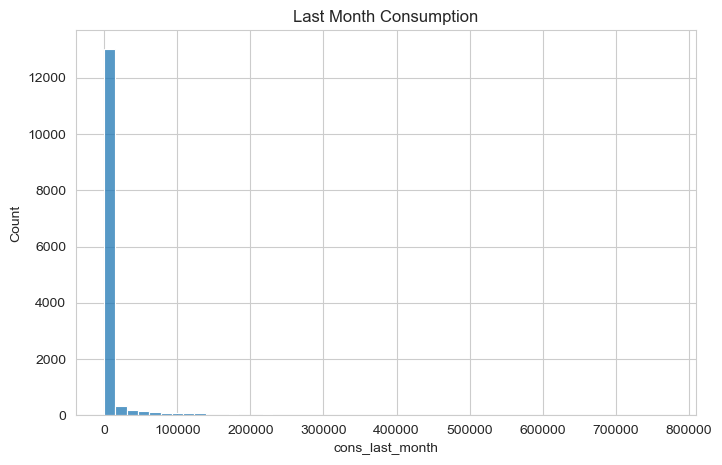

In [15]:
# LAST MONTH CONSUMPTION

plt.figure(figsize=(8,5))

sns.histplot(
    client_df['cons_last_month'],
    bins=50
)

plt.title("Last Month Consumption")

plt.show()

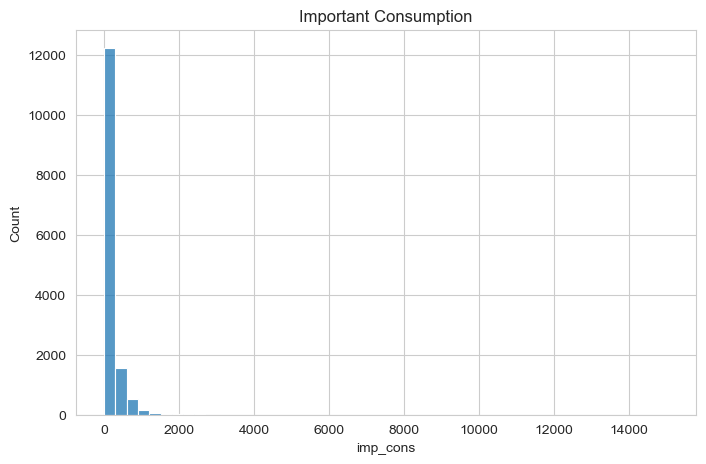

In [16]:
# IMPORTANT CONSUMPTION

plt.figure(figsize=(8,5))

sns.histplot(
    client_df['imp_cons'],
    bins=50
)

plt.title("Important Consumption")

plt.show()

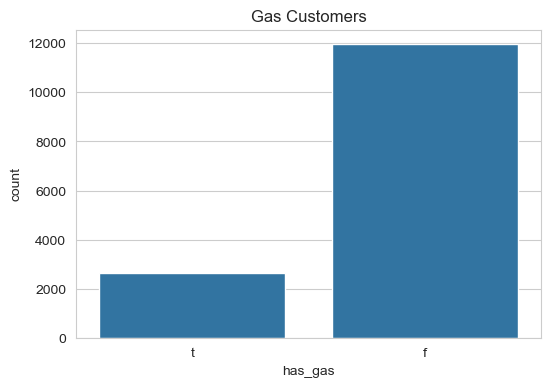

In [17]:
# GAS CUSTOMERS

plt.figure(figsize=(6,4))

sns.countplot(
    x='has_gas',
    data=client_df
)

plt.title("Gas Customers")

plt.show()

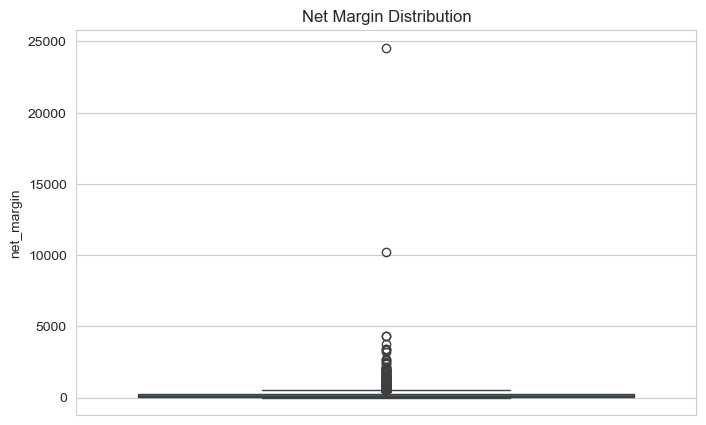

In [18]:
# NET MARGIN DISTRIBUTION

plt.figure(figsize=(8,5))

sns.boxplot(
    y=client_df['net_margin']
)

plt.title("Net Margin Distribution")

plt.show()

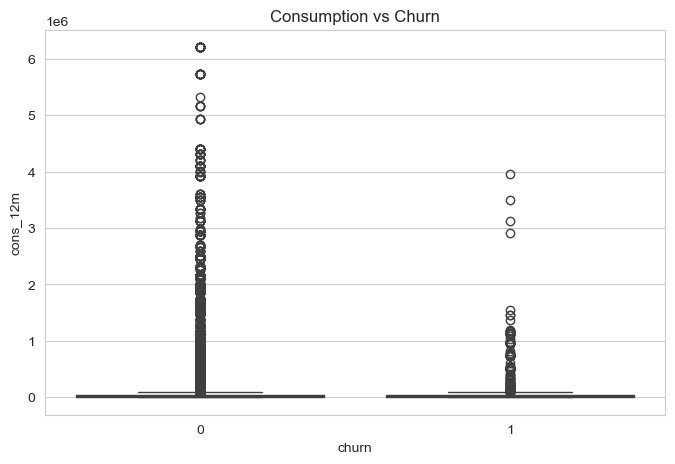

In [19]:
# CONSUMPTION VS CHURN

plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='cons_12m',
    data=client_df
)

plt.title("Consumption vs Churn")

plt.show()

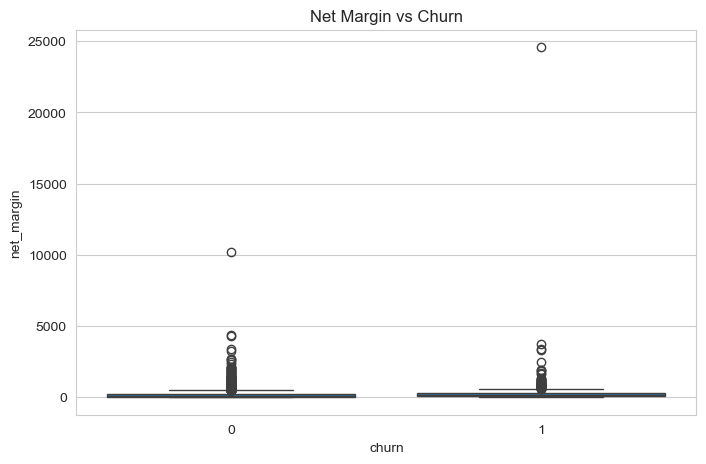

In [20]:
# NET MARGIN VS CHURN

plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='net_margin',
    data=client_df
)

plt.title("Net Margin vs Churn")

plt.show()

In [21]:
# CONTRACT LENGTH FEATURE

client_df['contract_length'] = (
    client_df['date_end']
    -
    client_df['date_activ']
).dt.days

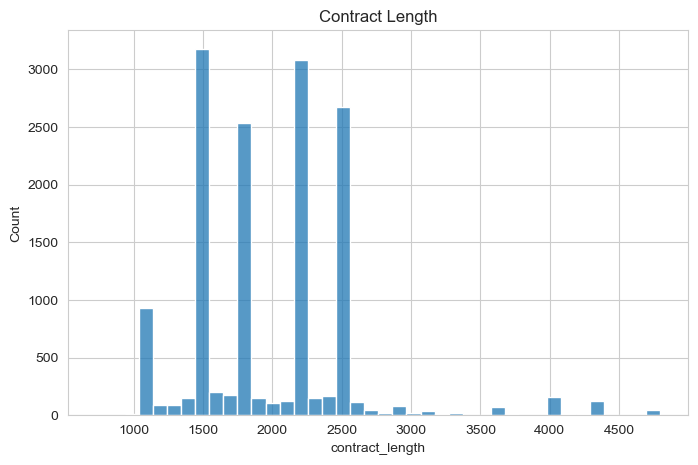

In [22]:
# CONTRACT LENGTH DISTRIBUTION

plt.figure(figsize=(8,5))

sns.histplot(
    client_df['contract_length'],
    bins=40
)

plt.title("Contract Length")

plt.show()

In [23]:
# MERGE DATASETS

merged_df = pd.merge(
    client_df,
    price_df,
    on='id'
)

merged_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,pow_max,churn,contract_length,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,43.648,1,1096,2015-01-01,0.125976,0.103395,0.071536,40.565969,24.339581,16.226389
1,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,43.648,1,1096,2015-02-01,0.125976,0.103395,0.071536,40.565969,24.339581,16.226389
2,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,43.648,1,1096,2015-03-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383
3,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,43.648,1,1096,2015-04-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383
4,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,43.648,1,1096,2015-05-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383


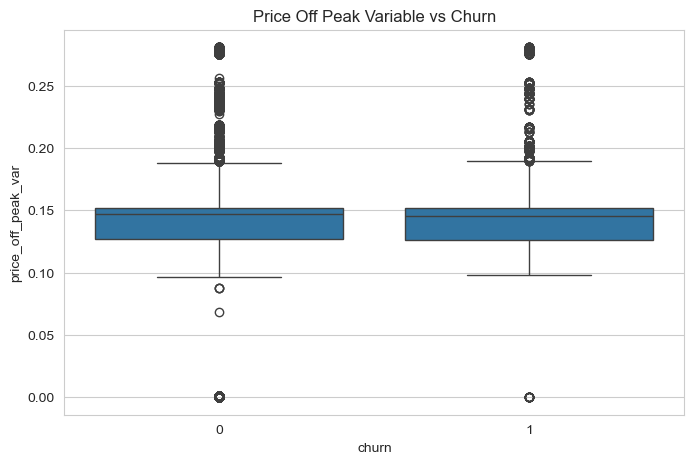

In [24]:
# PRICE OFF PEAK VARIABLE

plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='price_off_peak_var',
    data=merged_df
)

plt.title("Price Off Peak Variable vs Churn")

plt.show()

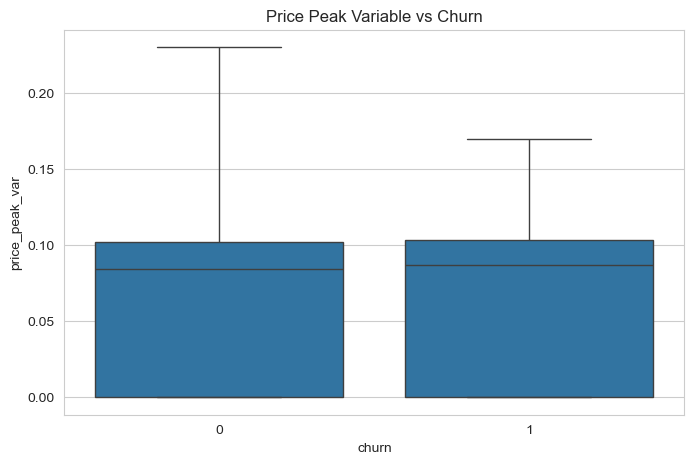

In [25]:
# PRICE PEAK VARIABLE

plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='price_peak_var',
    data=merged_df
)

plt.title("Price Peak Variable vs Churn")

plt.show()

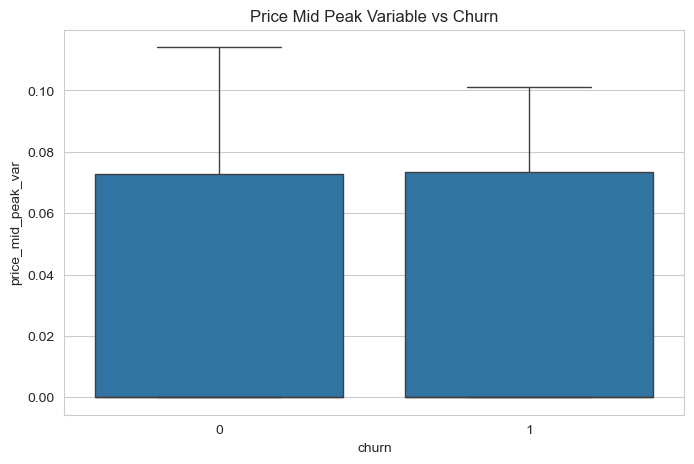

In [26]:
# PRICE MID PEAK VARIABLE

plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='price_mid_peak_var',
    data=merged_df
)

plt.title("Price Mid Peak Variable vs Churn")

plt.show()

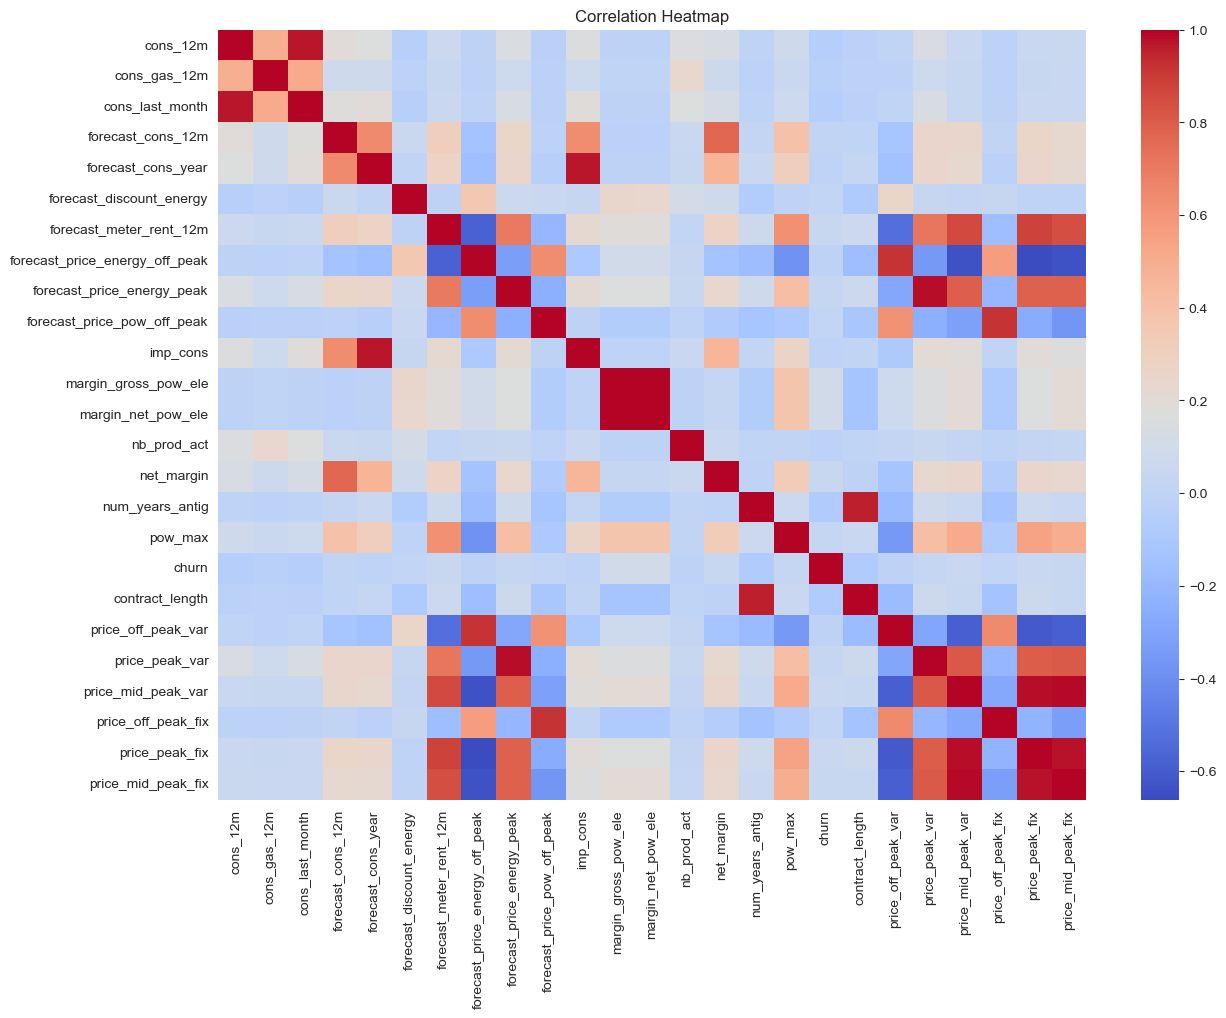

In [27]:
# CORRELATION HEATMAP

plt.figure(figsize=(14,10))

correlation = merged_df.select_dtypes(
    include=['int64', 'float64']
).corr()

sns.heatmap(
    correlation,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [28]:
# CORRELATION WITH CHURN

correlation['churn'].sort_values(
    ascending=False
)

churn                             1.000000
margin_net_pow_ele                0.095820
margin_gross_pow_ele              0.095774
price_peak_fix                    0.046852
price_mid_peak_var                0.046120
price_mid_peak_fix                0.044446
forecast_meter_rent_12m           0.044257
net_margin                        0.041077
pow_max                           0.030414
price_peak_var                    0.029314
forecast_price_energy_peak        0.029254
forecast_discount_energy          0.017113
price_off_peak_fix                0.016643
forecast_price_pow_off_peak       0.014872
forecast_cons_12m                 0.012882
imp_cons                         -0.001552
forecast_cons_year               -0.002540
price_off_peak_var               -0.006075
forecast_price_energy_off_peak   -0.010703
nb_prod_act                      -0.014780
cons_gas_12m                     -0.037897
cons_last_month                  -0.045237
cons_12m                         -0.045918
contract_le

In [29]:
# TOP SALES CHANNELS

client_df['channel_sales'].value_counts().head(10)

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

In [34]:
# TOP ORIGIN TYPES

client_df['origin_up'].value_counts().head(10)

origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64

In [31]:
# DUPLICATE VALUES

client_df.duplicated().sum()

np.int64(0)

In [32]:
# SKEWNESS

numerical_cols = client_df.select_dtypes(
    include=['int64', 'float64']
)

numerical_cols.skew().sort_values(
    ascending=False
)

net_margin                        36.569515
forecast_cons_year                16.587990
imp_cons                          13.198799
cons_gas_12m                       9.597530
nb_prod_act                        8.636878
forecast_cons_12m                  7.155853
cons_last_month                    6.391407
cons_12m                           5.997308
pow_max                            5.786785
forecast_discount_energy           5.155098
margin_net_pow_ele                 4.473326
margin_gross_pow_ele               4.472632
churn                              2.720715
forecast_meter_rent_12m            1.505148
num_years_antig                    1.446214
contract_length                    1.252599
forecast_price_energy_peak        -0.014331
forecast_price_energy_off_peak    -0.119586
forecast_price_pow_off_peak       -4.998772
dtype: float64